# **Mastering the Digit Recognizer: Accelerating KNN with PCA**

High-dimensional datasets slow down distance-based algorithms like K-Nearest Neighbors (KNN). This notebook demonstrates how to apply Principal Component Analysis (PCA) to pixel data to significantly reduce training time while maintaining high predictive accuracy. We establish a baseline KNN model on the raw image vectors and compare it against a PCA-optimized pipeline.

## **1. Imports and Setup**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## **2. Data Loading and Exploration**

Load the training data and examine its dimensions. The dataset consists of 784 pixel values per image (representing a 28x28 grid).

In [ ]:
df = pd.read_csv('dataset.csv')
print(f"Dataset Shape: {df.shape}")
display(df.sample(5))

Dataset Shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
40196,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
259,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20946,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40746,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
170,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **3. Visualizing the Dataset**

Plotting a sample of the images ensures the pixel arrays reshape correctly into standard characters.

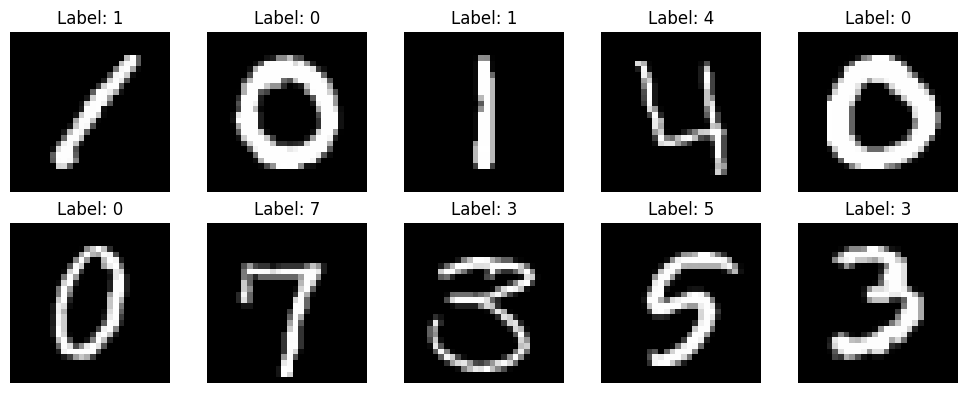

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = df.iloc[i, 1:].values.reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {df.iloc[i, 0]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## **4. Data Preprocessing**

Separate the feature matrix and the target labels, then allocate 20% of the data for testing.

In [4]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Training Features Shape: (33600, 784)
Testing Features Shape: (8400, 784)


## **5. Baseline Model: KNN on Raw Pixels**

Train a standard KNN classifier on the raw 784-dimensional dataset to establish performance and latency benchmarks.

In [5]:
knn_base = KNeighborsClassifier()

start_time = time.time()
knn_base.fit(X_train, y_train)
y_pred_base = knn_base.predict(X_test)
base_time = time.time() - start_time

base_accuracy = accuracy_score(y_test, y_pred_base)

print(f"Baseline Accuracy: {base_accuracy * 100:.2f}%")
print(f"Execution Time: {base_time:.2f} seconds")

Baseline Accuracy: 96.49%
Execution Time: 10.83 seconds


## **6. Dimensionality Reduction with PCA**

PCA projects the data onto a lower-dimensional space while preserving variance. Because PCA finds directions of maximum variance, it is highly sensitive to feature scaling. We must scale the data so that it has a mean of 0 and a standard deviation of 1:

$$ Z = \frac{X - \mu}{\sigma} $$

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA to extract the top 100 components
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Reduced Training Features Shape: {X_train_pca.shape}")

Reduced Training Features Shape: (33600, 100)


## **7. Optimized Model Evaluation**

Train the same KNN classifier on the compressed 100-dimensional data and compare the accuracy and execution time against the baseline.

In [7]:
knn_pca = KNeighborsClassifier()

start_time = time.time()
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)
pca_time = time.time() - start_time

pca_accuracy = accuracy_score(y_test, y_pred_pca)

print(f"PCA Accuracy: {pca_accuracy * 100:.2f}%")
print(f"PCA Execution Time: {pca_time:.2f} seconds")

PCA Accuracy: 95.44%
PCA Execution Time: 1.76 seconds


## **8. Finding the Optimal Components**

Brute-forcing KNN over all 784 dimensions is computationally expensive. A faster, more professional approach is to calculate the cumulative explained variance. This reveals the exact number of principal components required to retain a specific percentage (e.g., 90% or 95%) of the original dataset's information.

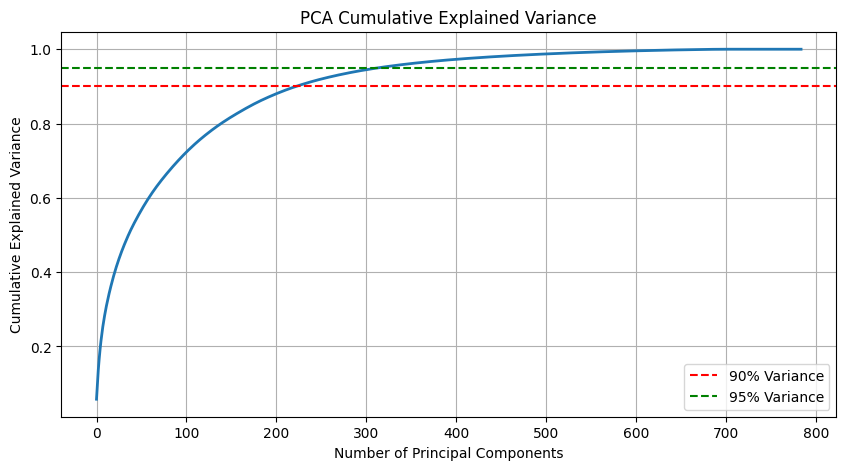

In [8]:
pca_full = PCA().fit(X_train_scaled)

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.legend(loc='best')
plt.grid(True)
plt.show()